# Lab 4: Fourier and Inverse Fourier Transform, Smoothing and Sharpening filters

### 1. Program to compute Fourier Transform and Inverse Fourier Transform and visualize the magnitude and Phase response

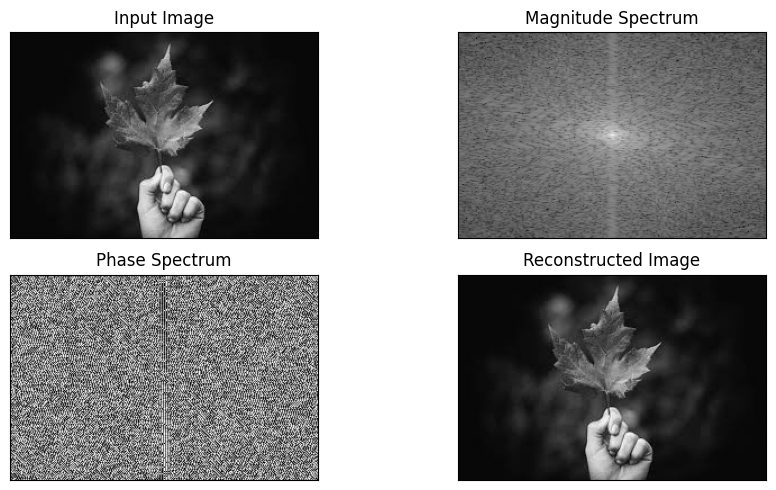

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("./img/red-leaf.jpg", cv2.IMREAD_GRAYSCALE)

dft = np.fft.fft2(image)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(np.abs(dft_shift))
phase_spectrum = np.angle(dft_shift)

idft_shift_original = np.fft.ifftshift(dft_shift)
idft_original = np.fft.ifft2(idft_shift_original)
idft_original = np.abs(idft_original)

plt.figure(figsize = (10, 5))

plt.subplot(221)
plt.imshow(image, cmap = 'gray')
plt.title('Input Image')
plt.xticks([])
plt.yticks([])

plt.subplot(222)
plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum')
plt.xticks([])
plt.yticks([])

plt.subplot(223)
plt.imshow(phase_spectrum, cmap = 'gray')
plt.title('Phase Spectrum')
plt.xticks([])
plt.yticks([])

plt.subplot(224)
plt.imshow(idft_original, cmap = 'gray')
plt.title('Reconstructed Image')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

### 2. Program to use various smoothing and sharpening filters and visualize its effects

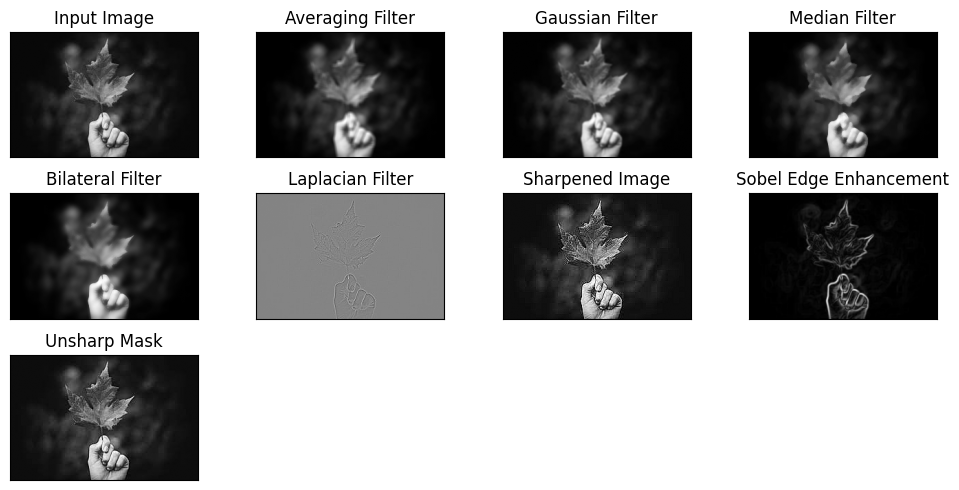

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

image = cv2.imread("./img/red-leaf.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize = (10, 5))

plt.subplot(341)
plt.imshow(image, cmap = 'gray')
plt.title('Input Image')
plt.xticks([])
plt.yticks([])

# Smoothing filters
# 1. Averaging (Box) Filter
avg_filter = cv2.blur(image, (5, 5))
plt.subplot(342)
plt.imshow(avg_filter, cmap = 'gray')
plt.title('Averaging Filter')
plt.xticks([])
plt.yticks([])

# 2. Gaussian Filter
gaussian_filter = cv2.GaussianBlur(image, (5, 5), 0)
plt.subplot(343)
plt.imshow(gaussian_filter, cmap = 'gray')
plt.title('Gaussian Filter')
plt.xticks([])
plt.yticks([])

# 3. Median Filter
median_filter = cv2.medianBlur(image, 5)
plt.subplot(344)
plt.imshow(median_filter, cmap = 'gray')
plt.title('Median Filter')
plt.xticks([])
plt.yticks([])

# 4. Bilateral Filter
bilateral_filter = cv2.bilateralFilter(image, 9, 75, 75)
plt.subplot(345)
plt.imshow(bilateral_filter, cmap = 'gray')
plt.title('Bilateral Filter')
plt.xticks([])
plt.yticks([])

# Sharpening filters
# 1. Laplacian Filter
laplacian_filter = cv2.Laplacian(image, cv2.CV_64F)
plt.subplot(346)
plt.imshow(laplacian_filter, cmap = 'gray')
plt.title('Laplacian Filter')
plt.xticks([])
plt.yticks([])

# 2. Custom Sharpening Kernel
sharpening_kernel = np.array([[0, -1, 0],
                                [-1, 5, -1],
                                [0, -1, 0]])
sharpened_image = cv2.filter2D(image, -1, sharpening_kernel)
plt.subplot(347)
plt.imshow(sharpened_image, cmap = 'gray')
plt.title('Sharpened Image')
plt.xticks([])
plt.yticks([])

# Sobel Edge Enhancement
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
plt.subplot(348)
plt.imshow(sobel_combined, cmap = 'gray')
plt.title('Sobel Edge Enhancement')
plt.xticks([])
plt.yticks([])

# Unsharp Mask
gaussian_blur = cv2.GaussianBlur(image, (5, 5), 0)
unsharp_mask = cv2.addWeighted(image, 2, gaussian_blur, -1, 0)
plt.subplot(349)
plt.imshow(unsharp_mask, cmap = 'gray')
plt.title('Unsharp Mask')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()